## Desafio D — Sistema de Registro de Preços

### Problema

Quais características diferenciam contratações realizadas com e sem Sistema de Registro de Preços?

### Possíveis perguntas

- O SRP é mais frequente em determinados tipos de contratação?
- Existem diferenças nos valores das contratações?
- Determinados órgãos utilizam SRP proporcionalmente mais do que outros?

### Variável de interesse

Quando disponível:

```text
srp
```

### Possíveis análises

- proporções;
- tabelas cruzadas;
- comparação de valores;
- teste qui-quadrado.


documentação API: https://dadosabertos.compras.gov.br/swagger-ui/index.html


## Instalação e importação das bibliotecas utilizadas

In [65]:
#!pip install requests pandas matplotlib -q
#!pip install pyarrow
#!pip install scipy

In [69]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import chi2_contingency, mannwhitneyu

## Pegando a base do ENDPOINT para a consulta da API

In [3]:
BASE_URL = "https://dadosabertos.compras.gov.br"

ENDPOINT_CONTRATACOES = "/modulo-contratacoes/1_consultarContratacoes_PNCP_14133"

url = BASE_URL + ENDPOINT_CONTRATACOES

print(url)

https://dadosabertos.compras.gov.br/modulo-contratacoes/1_consultarContratacoes_PNCP_14133


## Criando função para extrair os registros e dados da API

In [ ]:
def extrair_registros(json_resposta):

    if isinstance(json_resposta, list): # Se a reposta ja for uma lista, ele apenas retorna ela
        return json_resposta

    if not isinstance(json_resposta, dict):  # Se a reposta nao for uma lista e nem um dicionario, ele apenas retorna uma lista vazia para reagir a respostas inesperadas
        return []

    for chave in ["resultado", "resultados", "data", "content"]: # Checa se no dicionario as  inormações vieram por esse nome
        if chave in json_resposta and isinstance(json_resposta[chave], list):
            return json_resposta[chave] # Se veio essas chaves e se o valor associado a ele tambem veio, retorna os dados

    return [] # Se ele não achar nada, retorna a lista vazia



# Coleta de Dados

## Escolha dos dados
A seguir serão coletados os dados referente ao ano de 2024 e 2025, nas modalidades de pregão-eletronico e dispensa, com o objetivo de analisar o SRP e fazer uma analise de dados 

## Coletando dados de 2024

In [5]:
modalidades = [5, 6] # Pega principais modalidades
todos_registros = []

In [6]:
for modalidade in modalidades:
    pagina = 1
    total_modalidade = 0

    while True:
        params = {
            "pagina": pagina,
            "tamanhoPagina": 500,
            "dataPublicacaoPncpInicial": "2024-01-01",
            "dataPublicacaoPncpFinal": "2024-12-31",
            "codigoModalidade": modalidade
        }

        resposta = requests.get(url, params=params, timeout=60)

        if resposta.status_code == 429:
            espera = 5
            print(f"Modalidade {modalidade}, página {pagina}: 429, aguardando {espera}s e tentando de novo...")
            time.sleep(espera)
            continue  # tenta a mesma página de novo, sem avançar

        if resposta.status_code != 200:
            print(f"Modalidade {modalidade}, página {pagina}: erro {resposta.status_code}")
            break

        dados = resposta.json()
        registros = extrair_registros(dados)

        if not registros:
            break

        todos_registros.extend(registros)
        total_modalidade += len(registros)

        if len(registros) < 500:
            break

        pagina += 1
        time.sleep(0.2)  # pausa maior entre páginas

    print(f"Modalidade {modalidade}: {total_modalidade} registros coletados.")
    time.sleep(3)  # pausa entre modalidades, para o servidor "esfriar"

Modalidade 5: 104142 registros coletados.
Modalidade 6: 133930 registros coletados.


In [ ]:
df_24 = pd.json_normalize(todos_registros)
df_24.head()

,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,tipoInstrumentoConvocatorioNome,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida
0,17013105000172023,00394460000141-1-001631/2023,2023,1631,00394460000141,NaN,45178,MINISTERIO DA FAZENDA,NaN,F,...,Edital,Aberto-Fechado,614963.83,343793.5,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T09:00:00,2024-01-22T10:00:00,False
1,41300105000262023,02030715000112-1-000226/2023,2023,226,02030715000112,NaN,89804,AGENCIA NACIONAL DE TELECOMUNICACOES,NaN,F,...,Edital,Aberto-Fechado,404.74,NaN,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T08:00:00,2024-01-17T10:00:00,False
2,15812605000492023,10729992000146-1-000127/2023,2023,127,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Edital,Aberto-Fechado,105000.00,105000.0,2024-01-02T07:00:05,2024-01-15T07:07:29,2024-01-02T07:00:05,2024-01-02T08:00:00,2024-01-16T10:00:00,False
3,12006005000362023,00394429000100-1-002260/2023,2023,2260,00394429000100,NaN,43849,COMANDO DA AERONAUTICA,NaN,F,...,Edital,Aberto,286011.82,270000.0,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T08:00:00,2024-01-17T09:00:00,False
4,51017805000112023,29979036000140-1-000084/2023,2023,84,29979036000140,NaN,26661,INSTITUTO NACIONAL DO SEGURO SOCIAL,NaN,F,...,Edital,Aberto,232490.96,NaN,2024-01-02T07:00:09,2024-02-28T07:09:02,2024-01-02T07:00:09,2024-01-02T09:00:00,2024-01-16T09:00:00,False


In [ ]:

df_24["ano"] = 2024 # Adiciona a coluna "ano" a fim de saber o ano da contribuição

df_24.to_parquet("raw_completo_2024.parquet", index=False) # Salva parquet de 2024


if 'srp' in df_24.columns: # Verifica se o SRP veio na tabela
    print("\nValores brutos encontrados na coluna SRP:")
    print(df_24['srp'].value_counts(dropna=False)) # Vê quantos valores diferentes vieram para verificar valores nulos

    # Cria uma tabela auxiliar com os dados de 2024
    df_24_com_srp = df_24[df_24['srp'] == True] 
    df_24_sem_srp = df_24[df_24['srp'] == False]

    # Mostra quantos valores vieram em cada um
    print(f"\n Total COM SRP: {len(df_24_com_srp)}")
    print(f" Total SEM SRP: {len(df_24_sem_srp)}")



Valores brutos encontrados na coluna SRP:
srp
False    194102
True      43970
Name: count, dtype: int64

 Total COM SRP: 43970
 Total SEM SRP: 194102


In [ ]:
# Mostra os dataframes criados
print("\nDataFrame com SRP:")
display(df_24_com_srp.head())
print("\nDataFrame sem SRP:")
display(df_24_sem_srp.head())


DataFrame com SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
0,17013105000172023,00394460000141-1-001631/2023,2023,1631,00394460000141,NaN,45178,MINISTERIO DA FAZENDA,NaN,F,...,Aberto-Fechado,614963.83,343793.50,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T09:00:00,2024-01-22T10:00:00,False,2024
7,92804805900012024,88830609000139-1-000001/2024,2024,1,88830609000139,NaN,41243,MUNICIPIO DE CAXIAS DO SUL,NaN,M,...,Aberto,68469.70,27300.60,2024-01-02T07:00:16,2024-01-02T07:00:16,2024-01-02T07:00:16,2024-01-02T08:00:00,2024-01-16T08:30:00,False,2024
9,15590105000962023,15126437000143-1-003231/2023,2023,3231,15126437000143,NaN,95159,EMPRESA BRASILEIRA DE SERVIÇOS HOSPITALARES,NaN,F,...,Aberto-Fechado,137987.47,103025.62,2024-01-02T07:00:20,2024-01-02T07:00:20,2024-01-02T07:00:20,2024-01-02T08:00:00,2024-01-12T09:00:00,False,2024
11,15812605000352023,10729992000146-1-000128/2023,2023,128,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Aberto,13225.77,1600.00,2024-01-02T07:00:23,2024-01-02T07:00:23,2024-01-02T07:00:23,2024-01-02T08:00:00,2024-01-22T10:00:00,False,2024
12,16039905000432023,00394452000103-1-014522/2023,2023,14522,00394452000103,NaN,44611,COMANDO DO EXERCITO,NaN,F,...,Aberto-Fechado,6389632.82,1145924.50,2024-01-02T07:00:24,2024-01-05T07:04:20,2024-01-02T07:00:24,2024-01-05T08:00:00,2024-01-17T09:00:00,False,2024



DataFrame sem SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
1,41300105000262023,02030715000112-1-000226/2023,2023,226,02030715000112,NaN,89804,AGENCIA NACIONAL DE TELECOMUNICACOES,NaN,F,...,Aberto-Fechado,404.74,NaN,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T08:00:00,2024-01-17T10:00:00,False,2024
2,15812605000492023,10729992000146-1-000127/2023,2023,127,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Aberto-Fechado,105000.00,105000.0,2024-01-02T07:00:05,2024-01-15T07:07:29,2024-01-02T07:00:05,2024-01-02T08:00:00,2024-01-16T10:00:00,False,2024
3,12006005000362023,00394429000100-1-002260/2023,2023,2260,00394429000100,NaN,43849,COMANDO DA AERONAUTICA,NaN,F,...,Aberto,286011.82,270000.0,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T08:00:00,2024-01-17T09:00:00,False,2024
4,51017805000112023,29979036000140-1-000084/2023,2023,84,29979036000140,NaN,26661,INSTITUTO NACIONAL DO SEGURO SOCIAL,NaN,F,...,Aberto,232490.96,NaN,2024-01-02T07:00:09,2024-02-28T07:09:02,2024-01-02T07:00:09,2024-01-02T09:00:00,2024-01-16T09:00:00,False,2024
5,92668605000222023,04801221000110-1-000444/2023,2023,444,04801221000110,NaN,53800,TRIBUNAL DE CONTAS DO ESTADO DE RONDONIA,NaN,E,...,Aberto,99975.00,95466.0,2024-01-02T07:00:10,2024-01-02T07:00:10,2024-01-02T07:00:10,2024-01-02T08:00:00,2024-01-16T10:00:00,False,2024


In [ ]:
# Dataframe utiliando GroupBy agregando com nunique (únicos) e count (total de registros)
df_qnt_modalidade_orgao_24 = df_24.groupby('srp').agg(
    qtd_modalidades=('modalidadeNome', 'nunique'),
    qtd_orgaos=('orgaoEntidadeRazaoSocial', 'nunique'),
    total_registros=('numeroCompra', 'count')
)

df_qnt_modalidade_orgao_24.index = ['Sem SRP', 'Com SRP'] # Renomeia os índices para facilitar a leitura no relatório

display(df_qnt_modalidade_orgao_24)

,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2463,194102
Com SRP,3,1423,43970


# Pegando dados 2025

In [11]:
modalidades = [5, 6] # Pega principais modalidades
todos_registros = []

In [12]:
for modalidade in modalidades:
    pagina = 1
    total_modalidade = 0

    while True:
        params = {
            "pagina": pagina,
            "tamanhoPagina": 500,
            "dataPublicacaoPncpInicial": "2025-01-01",
            "dataPublicacaoPncpFinal": "2025-12-31",
            "codigoModalidade": modalidade,
        }

        resposta = requests.get(url, params=params, timeout=60)

        if resposta.status_code == 429:
            espera = 5
            print(f"Modalidade {modalidade}, página {pagina}: 429, aguardando {espera}s e tentando de novo...")
            time.sleep(espera)
            continue  # tenta a mesma página de novo, sem avançar

        if resposta.status_code != 200:
            print(f"Modalidade {modalidade}, página {pagina}: erro {resposta.status_code}")
            break

        dados = resposta.json()
        registros = extrair_registros(dados)

        if not registros:
            break

        todos_registros.extend(registros)
        total_modalidade += len(registros)

        if len(registros) < 500:
            break

        pagina += 1
        time.sleep(0.2)  # pausa maior entre páginas

    print(f"Modalidade {modalidade}: {total_modalidade} registros coletados.")
    time.sleep(3)  # pausa entre modalidades, para o servidor "esfriar"

Modalidade 5: 114824 registros coletados.
Modalidade 6: 131369 registros coletados.


In [ ]:
df_25 = pd.json_normalize(todos_registros)
df_25.head()

,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,tipoInstrumentoConvocatorioNome,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida
0,92647305900242024,06272868000127-1-000056/2024,2024,56,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Edital,Aberto-Fechado,400000.00,NaN,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T08:00:00,2025-01-16T09:00:00,False
1,92647305900252024,06272868000127-1-000057/2024,2024,57,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Edital,Aberto-Fechado,250782.10,151826.000,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T08:00:00,2025-01-14T09:00:00,False
2,38910305900162024,21947619000188-1-000068/2024,2024,68,21947619000188,NaN,21599,CONSELHO REGIONAL DE FISIOTERAPIA E TERAPIA OC...,NaN,F,...,Edital,Aberto-Fechado,868719.38,NaN,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:00:00,2025-01-17T09:00:00,False
3,94300105913862024,07954480000179-1-023839/2024,2024,23839,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Edital,Aberto-Fechado,11147211.58,6619438.535,2025-01-02T09:03:47,2025-05-09T08:13:51,2025-01-02T09:03:47,2025-04-25T08:00:00,2025-05-15T09:00:00,False
4,38918505900112024,00119784000171-1-000036/2024,2024,36,00119784000171,NaN,43167,CONSELHO FEDERAL DE MEDICINA VETERINARIA,NaN,F,...,Edital,Aberto,4612985.04,3718205.520,2025-01-02T09:03:51,2025-09-22T07:36:06,2025-01-02T09:03:51,2025-09-22T08:00:00,2025-10-07T10:00:00,False


In [ ]:
df_25["ano"] = 2025 # Adiciona a coluna "ano" a fim de saber o ano da contribuição

df_25.to_parquet("raw_completo_2025.parquet", index=False) # Salva parquet de 2025


if 'srp' in df_25.columns: # Verifica se o SRP veio na tabela
    
    print("\nValores brutos encontrados na coluna SRP:")
    print(df_25['srp'].value_counts(dropna=False))  # Vê quantos valores diferentes vieram para verificar valores nulos


    # Cria uma tabela auxiliar com os dados de 2025
    df_25_com_srp = df_25[df_25['srp'] == True]
    df_25_sem_srp = df_25[df_25['srp'] == False]

    # Mostra quantos valores vieram em cada um
    print(f"\n Total COM SRP: {len(df_25_com_srp)}")
    print(f" Total SEM SRP: {len(df_25_sem_srp)}")


Valores brutos encontrados na coluna SRP:
srp
False    193987
True      52206
Name: count, dtype: int64

 Total COM SRP: 52206
 Total SEM SRP: 193987


In [15]:
print("\nDataFrame com SRP:")
display(df_25_com_srp.head())
print("\nDataFrame sem SRP:")
display(df_25_sem_srp.head())


DataFrame com SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
5,94300105914952024,07954480000179-1-023841/2024,2024,23841,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,138742.18,89250.00,2025-01-02T09:03:57,2025-01-02T09:03:57,2025-01-02T09:03:57,2025-01-03T08:00:00,2025-01-15T14:30:00,False,2025
7,94300105913952024,07954480000179-1-023842/2024,2024,23842,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,759632.82,551284.00,2025-01-02T09:04:04,2025-01-02T09:04:04,2025-01-02T09:04:04,2025-01-03T08:00:00,2025-01-15T14:30:00,False,2025
8,94300105910162024,07954480000179-1-023843/2024,2024,23843,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,55242.57,37068.54,2025-01-02T09:04:07,2025-01-02T09:04:07,2025-01-02T09:04:07,2025-01-03T08:00:00,2025-01-15T09:00:00,False,2025
10,98748705900602024,75972760000160-1-000185/2024,2024,185,75972760000160,NaN,84922,MUNICIPIO DE CAPANEMA,NaN,M,...,Aberto,302156.25,206660.50,2025-01-02T09:04:14,2025-01-17T07:48:19,2025-01-02T09:04:14,2025-01-02T08:00:00,2025-01-21T08:30:00,False,2025
14,42512805900152024,02973240000106-1-000038/2024,2024,38,02973240000106,NaN,51122,ESTADO DO MARANHAO - SECRETARIA DE ESTADO DA S...,NaN,E,...,Aberto-Fechado,4425190.08,2782461.00,2025-01-02T09:04:26,2025-01-02T09:04:26,2025-01-02T09:04:26,2025-01-02T08:00:00,2025-01-15T09:00:00,False,2025



DataFrame sem SRP:


,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
0,92647305900242024,06272868000127-1-000056/2024,2024,56,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Aberto-Fechado,400000.00,NaN,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T09:03:34,2025-01-02T08:00:00,2025-01-16T09:00:00,False,2025
1,92647305900252024,06272868000127-1-000057/2024,2024,57,06272868000127,NaN,56302,CONSELHO REGIONAL DE ENFERMAGEM COREN MA,NaN,F,...,Aberto-Fechado,250782.10,151826.000,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T09:03:38,2025-01-02T08:00:00,2025-01-14T09:00:00,False,2025
2,38910305900162024,21947619000188-1-000068/2024,2024,68,21947619000188,NaN,21599,CONSELHO REGIONAL DE FISIOTERAPIA E TERAPIA OC...,NaN,F,...,Aberto-Fechado,868719.38,NaN,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:03:41,2025-01-02T09:00:00,2025-01-17T09:00:00,False,2025
3,94300105913862024,07954480000179-1-023839/2024,2024,23839,07954480000179,NaN,57870,ESTADO DO CEARA,NaN,E,...,Aberto-Fechado,11147211.58,6619438.535,2025-01-02T09:03:47,2025-05-09T08:13:51,2025-01-02T09:03:47,2025-04-25T08:00:00,2025-05-15T09:00:00,False,2025
4,38918505900112024,00119784000171-1-000036/2024,2024,36,00119784000171,NaN,43167,CONSELHO FEDERAL DE MEDICINA VETERINARIA,NaN,F,...,Aberto,4612985.04,3718205.520,2025-01-02T09:03:51,2025-09-22T07:36:06,2025-01-02T09:03:51,2025-09-22T08:00:00,2025-10-07T10:00:00,False,2025


In [ ]:
# GroupBy agregando com nunique (únicos) e count (total de registros)
df_qnt_modalidade_orgao_25 = df_25.groupby('srp').agg(
    qtd_modalidades=('modalidadeNome', 'nunique'),
    qtd_orgaos=('orgaoEntidadeRazaoSocial', 'nunique'),
    total_registros=('numeroCompra', 'count')
)

df_qnt_modalidade_orgao_25.index = ['Sem SRP', 'Com SRP'] # Renomeia os índices para facilitar a leitura no relatório

display(df_qnt_modalidade_orgao_25)

,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2871,193987
Com SRP,3,1646,52206


# Comparação 2024 X 2025

## Comparação das tabelas auxiliares 

In [53]:
display(df_qnt_modalidade_orgao_24)
display(df_qnt_modalidade_orgao_25)

,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2463,194102
Com SRP,3,1423,43970


,qtd_modalidades,qtd_orgaos,total_registros
Sem SRP,3,2871,193987
Com SRP,3,1646,52206


### Gera um dataframe final com a junção dos dados de 2024 e 2025

In [54]:
df_total = pd.concat([df_24, df_25], ignore_index=True)
df_total

,idCompra,numeroControlePNCP,anoCompraPncp,sequencialCompraPncp,orgaoEntidadeCnpj,orgaoSubrogadoCnpj,codigoOrgao,orgaoEntidadeRazaoSocial,orgaoSubrogadoRazaoSocial,orgaoEntidadeEsferaId,...,modoDisputaNomePncp,valorTotalEstimado,valorTotalHomologado,dataInclusaoPncp,dataAtualizacaoPncp,dataPublicacaoPncp,dataAberturaPropostaPncp,dataEncerramentoPropostaPncp,contratacaoExcluida,ano
0,17013105000172023,00394460000141-1-001631/2023,2023,1631,00394460000141,NaN,45178,MINISTERIO DA FAZENDA,NaN,F,...,Aberto-Fechado,614963.83,343793.50,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T07:00:02,2024-01-02T09:00:00,2024-01-22T10:00:00,False,2024
1,41300105000262023,02030715000112-1-000226/2023,2023,226,02030715000112,NaN,89804,AGENCIA NACIONAL DE TELECOMUNICACOES,NaN,F,...,Aberto-Fechado,404.74,NaN,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T07:00:04,2024-01-02T08:00:00,2024-01-17T10:00:00,False,2024
2,15812605000492023,10729992000146-1-000127/2023,2023,127,10729992000146,NaN,7087,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Aberto-Fechado,105000.00,105000.00,2024-01-02T07:00:05,2024-01-15T07:07:29,2024-01-02T07:00:05,2024-01-02T08:00:00,2024-01-16T10:00:00,False,2024
3,12006005000362023,00394429000100-1-002260/2023,2023,2260,00394429000100,NaN,43849,COMANDO DA AERONAUTICA,NaN,F,...,Aberto,286011.82,270000.00,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T07:00:07,2024-01-02T08:00:00,2024-01-17T09:00:00,False,2024
4,51017805000112023,29979036000140-1-000084/2023,2023,84,29979036000140,NaN,26661,INSTITUTO NACIONAL DO SEGURO SOCIAL,NaN,F,...,Aberto,232490.96,NaN,2024-01-02T07:00:09,2024-02-28T07:09:02,2024-01-02T07:00:09,2024-01-02T09:00:00,2024-01-16T09:00:00,False,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484260,16013706000462025,00394452000103-1-024933/2025,2025,24933,00394452000103,NaN,44611,COMANDO DO EXERCITO,NaN,F,...,Não se aplica,2040.48,2040.48,2025-12-30T20:15:02,2025-12-30T20:15:02,2025-12-30T20:15:02,NaN,NaN,False,2025
484261,13500206000312025,00348003002245-1-000544/2025,2025,544,00348003002245,NaN,97892,EMPRESA BRASILEIRA DE PESQUISA AGROPECUARIA,NaN,N,...,Não se aplica,157970.43,157970.43,2025-12-30T20:19:40,2025-12-30T20:19:40,2025-12-30T20:19:40,NaN,NaN,False,2025
484262,15814306001252025,10791831000182-1-000053/2025,2025,53,10791831000182,NaN,60822,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Não se aplica,1522362.00,1522362.00,2025-12-30T21:22:29,2025-12-30T21:22:29,2025-12-30T21:22:29,NaN,NaN,False,2025
484263,15814306001262025,10791831000182-1-000054/2025,2025,54,10791831000182,NaN,60822,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",NaN,F,...,Não se aplica,252900.00,252900.00,2025-12-30T21:35:41,2025-12-30T21:35:41,2025-12-30T21:35:41,NaN,NaN,False,2025


# Checamos duplicatas

In [55]:
# >>> AQUI ENTRA A CHECAGEM DE DUPLICATAS <
chave_dedup = [c for c in ['numeroCompra', 'orgaoEntidadeRazaoSocial', 'ano', 'modalidadeNome']
               if c in df_total.columns]
n_duplicados = df_total.duplicated(subset=chave_dedup).sum()
print(f"Duplicatas encontradas: {n_duplicados}")

if n_duplicados > 0:
    df_total = df_total.drop_duplicates(subset=chave_dedup)
    print(f"Total após remoção: {len(df_total)} registros")

Duplicatas encontradas: 215290
Total após remoção: 268975 registros


# Tratamento do dataframe final para pegar apenas as informações que queremos

In [56]:
# Lista com o nome exato das colunas de maior relevância
colunas_principais = [
    'srp', 'ano', 'numeroCompra', 'modalidadeNome',
    'unidadeOrgaoUfSigla',
    'unidadeOrgaoMunicipioNome',  
    'unidadeOrgaoCodigoIbge',     
    'orgaoEntidadeRazaoSocial', 'objetoCompra',
    'valorTotalEstimado', 'valorTotalHomologado', 'dataPublicacaoPncp',
]

# Seleciona apenas as colunas que realmente existem no df_total
colunas_presentes = [c for c in colunas_principais if c in df_total.columns]

# Cria um novo df para não mexer no original
df_final_reduzido = df_total[colunas_presentes].copy()

### Tratamento dos dados

In [ ]:
# Converte colunas financeiras para numérico (Float)
for col_valor in ['valorTotalEstimado', 'valorTotalHomologado']:
    if col_valor in df_final_reduzido.columns:
        df_final_reduzido[col_valor] = pd.to_numeric(
            df_final_reduzido[col_valor], errors='coerce'
        )

# Converte a data de publicação para formato de data real
if 'dataPublicacaoPncp' in df_final_reduzido.columns:
    df_final_reduzido['dataPublicacaoPncp'] = pd.to_datetime(
        df_final_reduzido['dataPublicacaoPncp'], errors='coerce'
    )



### Remoção da modalidade "Pregão - Presencial"
Como são poucos dados e diferem do que queremos, foi exlcuido a modalidade que é irrelevante

In [58]:
## Remoção da modalidade "Pregão - Presencial" 451
# Como são poucos dados e diferem do que queremos, foi excluída a modalidade que é irrelevante
df_final_reduzido = df_final_reduzido[df_final_reduzido['modalidadeNome'] != 'Pregão - Presencial'].copy()

print(f"Registros após remoção: {len(df_final_reduzido)}")
print(df_final_reduzido['modalidadeNome'].value_counts())

Registros após remoção: 268524
modalidadeNome
Pregão - Eletrônico    134585
Dispensa               133939
Name: count, dtype: int64


### Removendo valor homologado nulo

In [ ]:
# Decisão: mantido em df_nulos (dataset completo) e removido em df (usado para comparar valores homologados)
df_final = df_final_reduzido.dropna(subset=['valorTotalHomologado'])


## Dataframe final tratado

In [ ]:
print("=== DATAFRAME FINAL REDUZIDO ===")
print(f"Dimensões do DataFrame: {df_final.shape}")
display(df_final.head(10))

=== DATAFRAME FINAL REDUZIDO ===
Dimensões do DataFrame: (268524, 12)


,srp,ano,numeroCompra,modalidadeNome,unidadeOrgaoUfSigla,unidadeOrgaoMunicipioNome,unidadeOrgaoCodigoIbge,orgaoEntidadeRazaoSocial,objetoCompra,valorTotalEstimado,valorTotalHomologado,dataPublicacaoPncp
21209,True,2024,90057,Pregão - Eletrônico,SP,CAFELÂNDIA,3508801,MUNICIPIO DE CAFELANDIA,Registro de preço visando eventuais e futuras ...,1856089.00,1039693.92,2024-06-26 07:06:10
219442,False,2025,90038,Dispensa,PR,CASCAVEL,4104808,UNIVERSIDADE ESTADUAL DO OESTE DO PARANA,Câmera Intraoral.,6615.39,6509.00,2025-05-13 15:22:37
127849,False,2025,90001,Pregão - Eletrônico,MG,JUATUBA,3136652,MUNICIPIO DE JUATUBA,SRP futura e eventual aquisição de gêneros ali...,832789.40,785321.95,2025-01-30 07:11:54
3534,True,2024,90014,Pregão - Eletrônico,PR,TERRA ROXA,4127403,MUNICIPIO DE TERRA ROXA,"Contratação, Eventual e Futura de Empresa para...",340858.60,81347.40,2024-02-22 07:04:31
136325,True,2025,90017,Pregão - Eletrônico,BA,SALVADOR,2927408,MUNICIPIO DE SALVADOR,Aquisição de material para escritório (pranche...,854605.94,597747.40,2025-03-18 07:22:41
19847,True,2024,90136,Pregão - Eletrônico,SP,SÃO PAULO,3550308,HOSPITAL DAS CLINICAS DA FACULDADE DE MEDICINA...,Frasco plastico p/coleta de urina 24 hs,93230.09,84581.40,2024-06-19 07:06:59
99912,False,2024,601,Dispensa,SP,CAMPINAS,3509502,UNIVERSIDADE ESTADUAL DE CAMPINAS,"Aquisição de mesa, relógio e jogo de xadrez. p...",4150.00,4150.00,2024-09-13 12:44:31
265293,False,2025,7,Dispensa,SP,SÃO PAULO,3550308,SUBPREFEITURA SANTO AMARO,Contratação de empresa especializada para requ...,95519.55,NaN,2025-12-10 11:21:32
241303,False,2025,30,Dispensa,AM,MANAUS,1302603,CONSELHO REGIONAL DE PSICOLOGIA 20 REGIAO,Contratação de empresa de fornecimento de buff...,5600.00,5600.00,2025-08-26 12:45:58
144688,True,2025,90045,Pregão - Eletrônico,PB,JOÃO PESSOA,2507507,SECRETARIA DE ESTADO DA ADMINISTRACAO,Registro de preços para aquisição de material ...,1238437.80,NaN,2025-04-29 08:40:36


In [ ]:
df_final.to_parquet("srp_contratacoes_tratado_pais.parquet", index=False) # Salva a tabela final em parquet

In [63]:
df = pd.read_parquet("srp_contratacoes_tratado_pais.parquet") # Lê a tabela final salva em parquet
df_nulos = pd.read_parquet("srp_contratacoes_completo_com_nulos.parquet")

## Tamanho final da Tabela

In [60]:
print(df.shape)
df.sample(10)


(227988, 12)


,srp,ano,numeroCompra,modalidadeNome,unidadeOrgaoUfSigla,unidadeOrgaoMunicipioNome,unidadeOrgaoCodigoIbge,orgaoEntidadeRazaoSocial,objetoCompra,valorTotalEstimado,valorTotalHomologado,dataPublicacaoPncp
155094,False,2025,94064,Pregão - Eletrônico,MG,BELO HORIZONTE,3106200,MUNICIPIO DE BELO HORIZONTE,PE94064/2025 - Aquisição de itens ortopédicos,63631.29,42698.96,2025-10-24 07:03:04
159208,True,2025,90082,Pregão - Eletrônico,MG,JUIZ DE FORA,3136702,COMPANHIA DE SANEAMENTO MUNICIPAL - CESAMA,Implantação do Sistema de Registro de Preços p...,136194.80,122575.32,2025-11-14 07:05:27
90199,False,2024,689,Dispensa,RJ,RIO DE JANEIRO,3304557,FUNDACAO OSWALDO CRUZ,"Execução de atividades de apoio logístico, adm...",9468392.07,9468329.07,2024-10-18 16:00:47
115145,True,2025,90007,Pregão - Eletrônico,MG,JUIZ DE FORA,3136702,EMPRESA MUNICIPAL DE PAVIMENTACAO E URBANIDADE...,Futura e eventual aquisição de carretinhas reb...,218243.31,212610.00,2025-03-18 08:08:59
215501,False,2025,572,Dispensa,RS,PELOTAS,4314407,UNIVERSIDADE FEDERAL DE PELOTAS,"Aquisição de material de consumo, nos termos d...",3435.90,3435.90,2025-10-23 09:35:16
28161,False,2024,90006,Pregão - Eletrônico,SC,JOINVILLE,4209102,INST DE PREVID SOCIAL DOS SERV PUBL DO MUNIC D...,Contratação de pessoa jurídica para o fornecim...,13497.00,10697.50,2024-08-22 07:10:26
54257,False,2024,90002,Dispensa,ES,VITÓRIA,3205309,CONSELHO REGIONAL DE ENFERMAGEM DO ESPIRITO SANTO,Contratação de empresa organizadora de eventos...,32324.46,25990.00,2024-02-20 15:32:27
181534,False,2025,25,Dispensa,PE,RECIFE,2611606,FUNDACAO JOAQUIM NABUCO FUNDAJ,Prestação de serviços continuados de manutençã...,33600.00,33600.00,2025-04-17 17:01:47
205087,False,2025,40,Dispensa,RJ,RIO DE JANEIRO,3304557,INSTITUTO DO PATRIMONIO HISTORICO E ARTISTICO ...,Contratação de empresa para reparo emergencial...,1650.00,1650.00,2025-08-29 14:29:56
79942,False,2024,90041,Dispensa,MG,MONTES CLAROS,3143302,"INSTITUTO FEDERAL DE EDUCACAO, CIENCIA E TECNO...",Aquisição de material expediente,17975.64,9770.22,2024-08-23 08:59:53


In [72]:
plt.rcParams['figure.figsize'] = (8, 5)

# Pergunta 1



In [73]:
tabela1 = pd.crosstab(df_nulos['modalidadeNome'], df_nulos['srp'])
proporcao1 = pd.crosstab(df_nulos['modalidadeNome'], df_nulos['srp'], normalize='index') * 100

print("Contagem:")
display(tabela1)
print("\nProporção (%):")
display(proporcao1)

chi2, p1, gl, esperado = chi2_contingency(tabela1)
n = tabela1.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabela1.shape) - 1)))

print(f"\nQui-quadrado: {chi2:.2f} | p-valor: {p1:.4g} | graus de liberdade: {gl}")
print(f"Cramér's V: {cramers_v:.3f}")

Contagem:


srp,False,True
modalidadeNome,,
Dispensa,133592,347
Pregão - Eletrônico,70579,64006



Proporção (%):


srp,False,True
modalidadeNome,,
Dispensa,99.740927,0.259073
Pregão - Eletrônico,52.441951,47.558049



Qui-quadrado: 82416.42 | p-valor: 0 | graus de liberdade: 1
Cramér's V: 0.554


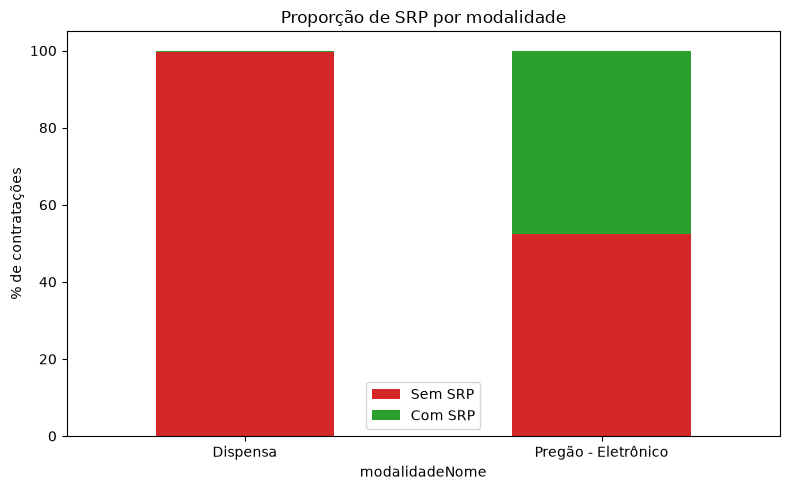

In [74]:
proporcao1.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'])
plt.ylabel('% de contratações')
plt.title('Proporção de SRP por modalidade')
plt.legend(['Sem SRP', 'Com SRP'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafico1_srp_por_modalidade.png', dpi=150)
plt.show()

Excelente resultado — e esse aqui é bem forte, não só estatisticamente significativo mas com um efeito prático grande.

O que os números dizem:

Na Dispensa, o SRP é praticamente inexistente: só 0,26% das contratações usam SRP (347 de 133.939).
No Pregão-Eletrônico, é quase meio a meio: 47,56% usam SRP.

Ou seja, a modalidade explica quase toda a variação de uso do SRP — não é um efeito sutil, é uma relação muito forte.

Sobre o p-valor "0": com uma amostra de quase 270 mil registros, praticamente qualquer diferença viraria "significativa" no sentido estatístico — então, sozinho, o p-valor não prova que o efeito é grande, só que ele é real (não é ruído aleatório). Quem prova que é grande é o Cramér's V = 0,554. Para uma tabela 2×2 (1 grau de liberdade), valores de referência comuns (Cohen) são: ~0,10 = efeito pequeno, ~0,30 = médio, ~0,50+ = grande. Seu 0,554 está na faixa de efeito grande — então aqui você tem os dois: significância estatística E relevância prática.

Faz sentido do ponto de vista legal, o que fortalece a interpretação: pela Lei 14.133/2021, o SRP é um instrumento tipicamente vinculado a licitações via Pregão (e Concorrência) — a Dispensa de Licitação é, por definição, uma contratação direta sem licitação competitiva, então o uso de SRP nesse contexto é excepcional (geralmente adesão a uma ata de registro de preço já existente em situações específicas). Isso explica por que 99,74% das Dispensas não usam SRP: não é uma "escolha" tão comum de gestor, é quase uma restrição estrutural do próprio instituto.

Para o relatório, uma frase resumo seria algo como: "O uso do SRP está fortemente associado à modalidade de contratação (χ² = 82.416,42; p < 0,001; V de Cramér = 0,554), sendo residual em Dispensas (0,26%) e comum em Pregões Eletrônicos (47,56%), o que é coerente com a natureza jurídica do instituto, tipicamente vinculado a processos licitatórios competitivos."

# Pergunta 2

In [75]:
com_srp_est = df_nulos[df_nulos['srp'] == True]['valorTotalEstimado'].dropna()
sem_srp_est = df_nulos[df_nulos['srp'] == False]['valorTotalEstimado'].dropna()

print("Mediana COM SRP (estimado):", com_srp_est.median())
print("Mediana SEM SRP (estimado):", sem_srp_est.median())

stat, p2a = mannwhitneyu(com_srp_est, sem_srp_est, alternative='two-sided')
print(f"Mann-Whitney U p-valor (estimado): {p2a:.4g}")

Mediana COM SRP (estimado): 433199.2
Mediana SEM SRP (estimado): 22500.0
Mann-Whitney U p-valor (estimado): 0


In [76]:
com_srp_hom = df[df['srp'] == True]['valorTotalHomologado']
sem_srp_hom = df[df['srp'] == False]['valorTotalHomologado']

print("Mediana COM SRP (homologado):", com_srp_hom.median())
print("Mediana SEM SRP (homologado):", sem_srp_hom.median())

stat, p2b = mannwhitneyu(com_srp_hom, sem_srp_hom, alternative='two-sided')
print(f"Mann-Whitney U p-valor (homologado): {p2b:.4g}")

Mediana COM SRP (homologado): 290690.07999999996
Mediana SEM SRP (homologado): 19201.21
Mann-Whitney U p-valor (homologado): 0


In [77]:
taxa_nao_homologado = df_nulos.groupby('srp')['valorTotalHomologado'].apply(lambda x: x.isna().mean()) * 100
print("Taxa de não-homologação (%):")
print(taxa_nao_homologado)

tabela_homologacao = pd.crosstab(df_nulos['srp'], df_nulos['valorTotalHomologado'].isna())
chi2_h, p_h, _, _ = chi2_contingency(tabela_homologacao)
print(f"\np-valor (diferença na taxa de homologação): {p_h:.4g}")

Taxa de não-homologação (%):
srp
False    15.697136
True     13.188196
Name: valorTotalHomologado, dtype: float64

p-valor (diferença na taxa de homologação): 3.712e-54


In [78]:
df['taxa_desagio'] = 1 - (df['valorTotalHomologado'] / df['valorTotalEstimado'])
print(df.groupby('srp')['taxa_desagio'].median())

srp
False    0.095558
True     0.331702
Name: taxa_desagio, dtype: float64


In [82]:
# Isola o efeito do SRP controlando pela modalidade (só Pregão-Eletrônico)
pregao = df_nulos[df_nulos['modalidadeNome'] == 'Pregão - Eletrônico']

com_srp_pregao = pregao[pregao['srp'] == True]['valorTotalEstimado'].dropna()
sem_srp_pregao = pregao[pregao['srp'] == False]['valorTotalEstimado'].dropna()

print("Mediana COM SRP (só Pregão):", com_srp_pregao.median())
print("Mediana SEM SRP (só Pregão):", sem_srp_pregao.median())

stat, p_pregao = mannwhitneyu(com_srp_pregao, sem_srp_pregao, alternative='two-sided')
print(f"p-valor: {p_pregao:.4g}")

Mediana COM SRP (só Pregão): 437830.5
Mediana SEM SRP (só Pregão): 192679.39
p-valor: 0


In [83]:
# Mesma lógica para a taxa de deságio, só dentro do Pregão-Eletrônico
df_pregao_taxa = df[df['modalidadeNome'] == 'Pregão - Eletrônico']
print(df_pregao_taxa.groupby('srp')['taxa_desagio'].median())

srp
False    0.266762
True     0.332712
Name: taxa_desagio, dtype: float64


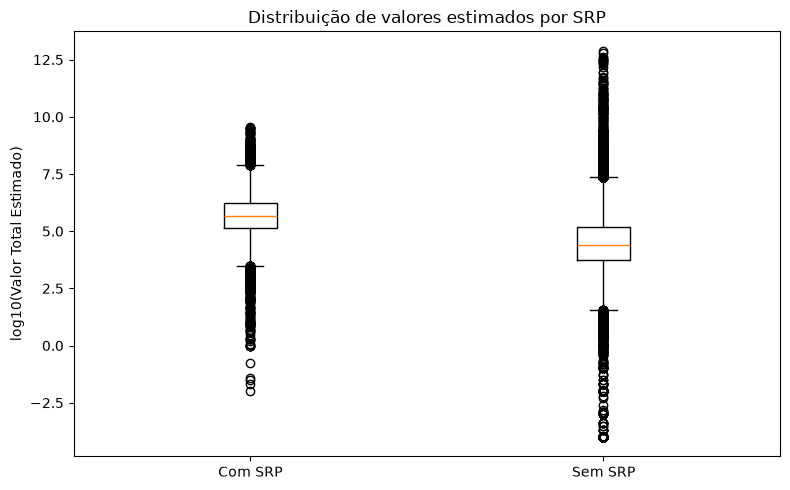

In [79]:
fig, ax = plt.subplots()
dados_log = [np.log10(com_srp_est[com_srp_est > 0]), np.log10(sem_srp_est[sem_srp_est > 0])]
ax.boxplot(dados_log, tick_labels=['Com SRP', 'Sem SRP'])
ax.set_ylabel('log10(Valor Total Estimado)')
ax.set_title('Distribuição de valores estimados por SRP')
plt.tight_layout()
plt.savefig('grafico2_valores_por_srp.png', dpi=150)
plt.show()

Interpretação:

O gap de valor estimado caiu de "19x maior" (comparação bruta, contaminada por modalidade) para "~2,3x maior" (controlado por modalidade) — ou seja, boa parte do efeito bruto era mesmo confundimento, mas sobra uma diferença real e substancial. Isso faz bastante sentido do ponto de vista de como o SRP funciona na prática: uma Ata de Registro de Preços costuma agregar quantidades maiores (o objetivo é registrar preços para consumo futuro, muitas vezes por vários órgãos/unidades ao longo de até 1 ano), então é esperado que o valor total estimado de um processo de SRP seja naturalmente maior — não necessariamente porque cada item é mais caro, mas porque o volume contratado é maior.

Isso também ajuda a explicar a taxa de deságio maior no SRP (33,27% vs 26,68%, mesmo controlando modalidade): processos de maior volume tendem a atrair mais fornecedores dispostos a competir agressivamente no preço, já que o "prêmio" de ganhar é maior (fornecer para múltiplos órgãos/período mais longo, não uma compra pontual).

Para o relatório, uma frase equilibrada seria:

"Ao controlar pela modalidade (comparando apenas dentro do Pregão-Eletrônico), o valor estimado de contratações com SRP permanece significativamente maior (mediana de R$ 437.830 vs R$ 192.679; p < 0,001), embora a magnitude da diferença seja bem menor que a comparação não controlada, indicando que parte do efeito bruto era confundido pela associação entre SRP e modalidade. O SRP também apresenta maior taxa de deságio mesmo controlando por modalidade (33,3% vs 26,7%), consistente com a hipótese de que o maior volume agregado nas Atas de Registro de Preços atrai maior competição entre fornecedores."

# Pergunta 3

In [80]:
volume_por_orgao = df_nulos.groupby('orgaoEntidadeRazaoSocial').size()
orgaos_relevantes = volume_por_orgao[volume_por_orgao >= 30].index
df_filtrado = df_nulos[df_nulos['orgaoEntidadeRazaoSocial'].isin(orgaos_relevantes)]

ranking = (
    df_filtrado.groupby('orgaoEntidadeRazaoSocial')['srp']
    .mean()
    .sort_values(ascending=False)
    .head(15) * 100
)
print(ranking)

orgaoEntidadeRazaoSocial
FUNDACAO DE EDUCACAO, TURISMO, ESPORTE E CULTURA DE BOA VISTA       100.000000
MUNICIPIO DE IRITUIA                                                100.000000
MUNICIPIO DE GOVERNADOR NEWTON BELLO                                100.000000
MUNICIPIO DE GOVERNADOR MANGABEIRA                                  100.000000
MUNICIPIO DE SAO DOMINGOS DO CAPIM                                  100.000000
MUNICIPIO DE BORDA DA MATA                                           99.000000
MUNICIPIO DE CURRAIS NOVOS                                           98.901099
MUNICIPIO DE SILVES                                                  98.701299
CONSORCIO PUBLICO INTERMUNICIPAL DE GESTAO DA AMUSEP - PROAMUSEP     97.674419
TRIBUNAL DE CONTAS DO ESTADO DO ACRE                                 97.435897
MUNICIPIO DE GIRAU DO PONCIANO                                       97.142857
MUNICIPIO DE PEIXE-BOI                                               96.774194
MUNICIPIO DE CACERES       

In [84]:
resumo_top = df_filtrado.groupby('orgaoEntidadeRazaoSocial')['srp'].agg(['mean', 'count'])
resumo_top['mean'] = resumo_top['mean'] * 100
print(resumo_top.sort_values('mean', ascending=False).head(15))

                                                          mean  count
orgaoEntidadeRazaoSocial                                             
FUNDACAO DE EDUCACAO, TURISMO, ESPORTE E CULTUR...  100.000000     39
MUNICIPIO DE IRITUIA                                100.000000     33
MUNICIPIO DE GOVERNADOR NEWTON BELLO                100.000000     32
MUNICIPIO DE GOVERNADOR MANGABEIRA                  100.000000     30
MUNICIPIO DE SAO DOMINGOS DO CAPIM                  100.000000     45
MUNICIPIO DE BORDA DA MATA                           99.000000    100
MUNICIPIO DE CURRAIS NOVOS                           98.901099     91
MUNICIPIO DE SILVES                                  98.701299     77
CONSORCIO PUBLICO INTERMUNICIPAL DE GESTAO DA A...   97.674419     43
TRIBUNAL DE CONTAS DO ESTADO DO ACRE                 97.435897     39
MUNICIPIO DE GIRAU DO PONCIANO                       97.142857     35
MUNICIPIO DE PEIXE-BOI                               96.774194     31
MUNICIPIO DE CACERES

In [85]:
df_bruto = pd.read_parquet("raw_completo_2024.parquet")  # ou o completo com nulos, se já tiver essa coluna
print(df_bruto['orgaoEntidadeEsferaId'].value_counts())

orgaoEntidadeEsferaId
F    109631
E     77230
M     45891
N      3438
D      1882
Name: count, dtype: int64


In [90]:
tabela_esfera = pd.crosstab(df_nulos['orgaoEntidadeEsferaId'], df_nulos['srp'], normalize='index') * 100
print(tabela_esfera)

tabela_esfera_bruta = pd.crosstab(df_nulos['orgaoEntidadeEsferaId'], df_nulos['srp'])
chi2_e, p_e, gl_e, esp_e = chi2_contingency(tabela_esfera_bruta)
n_e = tabela_esfera_bruta.sum().sum()
cramers_v_e = np.sqrt(chi2_e / (n_e * (min(tabela_esfera_bruta.shape) - 1)))

print(f"\nQui-quadrado: {chi2_e:.2f} | p-valor: {p_e:.4g} | Cramér's V: {cramers_v_e:.3f}")

srp                        False      True 
orgaoEntidadeEsferaId                      
D                      65.369786  34.630214
E                      74.935390  25.064610
F                      86.976506  13.023494
M                      68.164422  31.835578
N                      69.890438  30.109562

Qui-quadrado: 9401.97 | p-valor: 0 | Cramér's V: 0.187


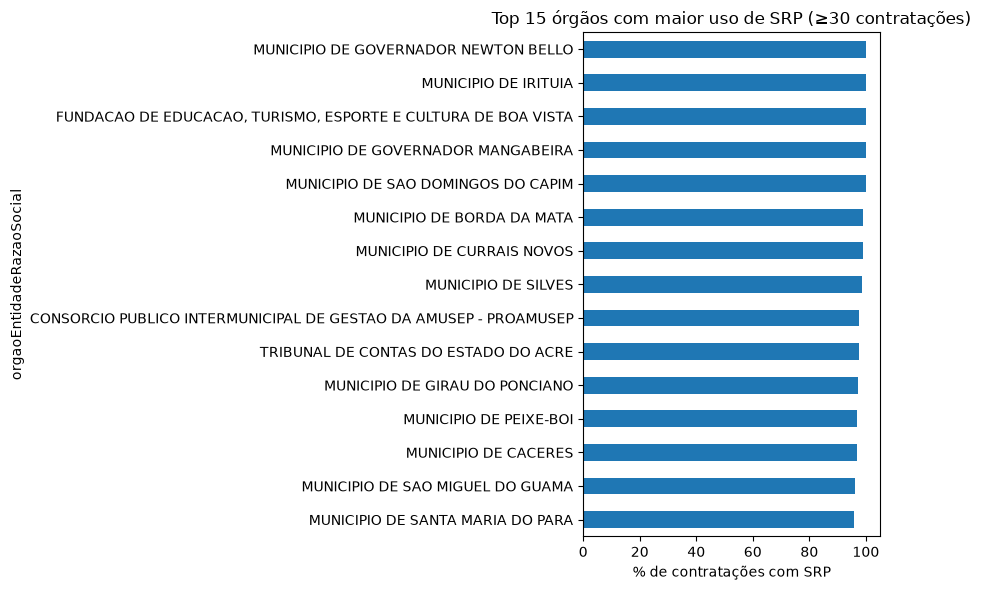

In [81]:
fig, ax = plt.subplots(figsize=(9, 6))
ranking.sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_xlabel('% de contratações com SRP')
ax.set_title('Top 15 órgãos com maior uso de SRP (≥30 contratações)')
plt.tight_layout()
plt.savefig('grafico3_ranking_orgaos.png', dpi=150)
plt.show()

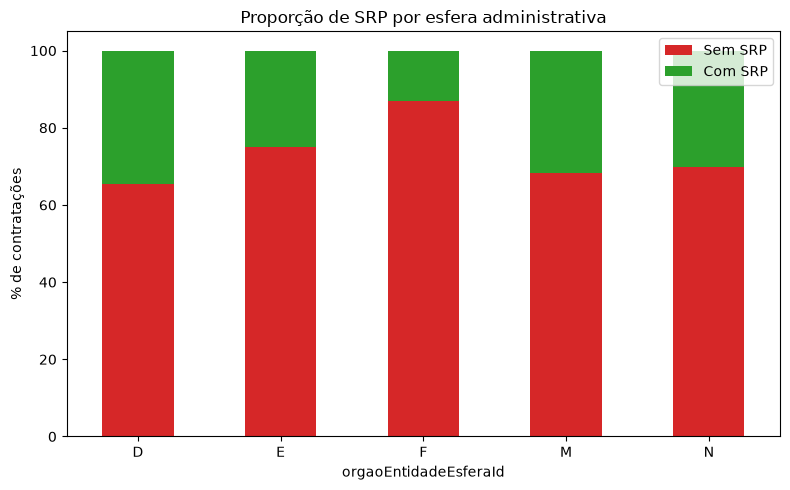

In [91]:
tabela_esfera.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'])
plt.ylabel('% de contratações')
plt.title('Proporção de SRP por esfera administrativa')
plt.legend(['Sem SRP', 'Com SRP'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('grafico5_srp_por_esfera.png', dpi=150)
plt.show()

In [92]:
mix_modalidade_esfera = pd.crosstab(df_nulos['orgaoEntidadeEsferaId'], df_nulos['modalidadeNome'], normalize='index') * 100
print(mix_modalidade_esfera)

modalidadeNome          Dispensa  Pregão - Eletrônico
orgaoEntidadeEsferaId                                
D                      42.832107            57.167893
E                      47.009865            52.990135
F                      70.535392            29.464608
M                      35.871434            64.128566
N                      32.001992            67.998008


In [93]:
pregao_esfera = pregao.merge(
    df_nulos[['numeroCompra', 'orgaoEntidadeRazaoSocial', 'ano', 'orgaoEntidadeEsferaId']],
    on=['numeroCompra', 'orgaoEntidadeRazaoSocial', 'ano'], how='left'
) if 'orgaoEntidadeEsferaId' not in pregao.columns else pregao

tabela_esfera_pregao = pd.crosstab(pregao_esfera['orgaoEntidadeEsferaId'], pregao_esfera['srp'], normalize='index') * 100
print(tabela_esfera_pregao)

srp                        False      True 
orgaoEntidadeEsferaId                      
D                      38.169336  61.830664
E                      54.758959  45.241041
F                      56.531986  43.468014
M                      50.935660  49.064340
N                      53.775620  46.224380


Resumo atualizado para o relatório (substituindo o anterior):

"A associação aparente entre esfera administrativa e uso de SRP é majoritariamente explicada pela modalidade: órgãos federais concentram 70,5% de suas contratações em Dispensa (modalidade em que o SRP é residual), contra 35,9% dos municípios. Ao controlar pela modalidade (comparando apenas dentro de Pregão-Eletrônico), as diferenças entre esferas se reduzem substancialmente — Federal (43,5%), Estadual (45,2%) e Municipal (49,1%) ficam próximos entre si, com Distrital destacando-se acima (61,8%, com ressalva de menor tamanho amostral). Isso indica que a esfera administrativa, isoladamente, tem influência limitada sobre a propensão ao SRP quando comparada ao efeito dominante da modalidade de contratação."